In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
rng = np.random.default_rng(42)


def generate_students(n=200, seed=42):
    
    hours_studied = rng.normal(5, 2, n).clip(1, 10)
    marks = (hours_studied * rng.uniform(8, 12, n) + rng.normal(0, 5, n)).clip(30, 100)
    gender = rng.choice(['Male', 'Female'], n)
    subject = rng.choice(['Math', 'Science', 'English', 'History'], n)
    study_method = rng.choice(['Solo', 'Group'], n, p=[0.6, 0.4])
    attempts = rng.integers(1, 4, n)

    return pd.DataFrame({
        'hours_studied': hours_studied.round(2),
        'marks': marks.round(2),
        'gender': gender,
        'subject': subject,
        'study_method': study_method,
        'attempts': attempts
    })

def generate_daily_sales(n=60, seed=42):
    rng = np.random.default_rng(seed)
    base = pd.date_range(start='2024-01-01', periods=n, freq='D')
    trend = np.linspace(50, 80, n)
    season = 8 * np.sin(np.linspace(0, 3*np.pi, n))
    noise = rng.normal(0, 3, n)
    sales = (trend + season + noise).round(2)
    return pd.DataFrame({'date': base, 'sales': sales})

students = generate_students(220, seed=42)
sales = generate_daily_sales(90, seed=42)

sns.set_theme(style="whitegrid")

#### Problem 1

<Axes: xlabel='date', ylabel='sales'>

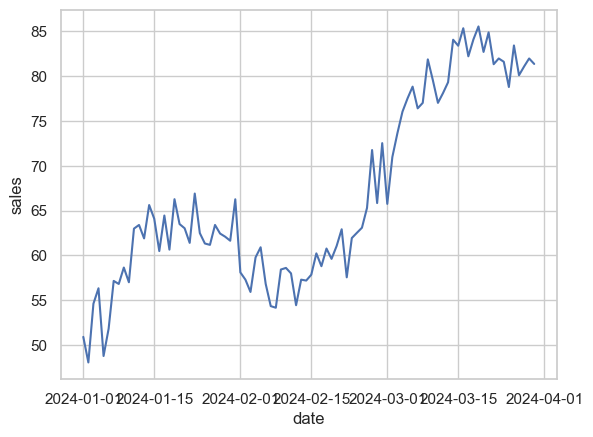

In [2]:
sns.lineplot(data=sales, x='date', y='sales')


### Problem 2

<Axes: xlabel='hours_studied', ylabel='marks'>

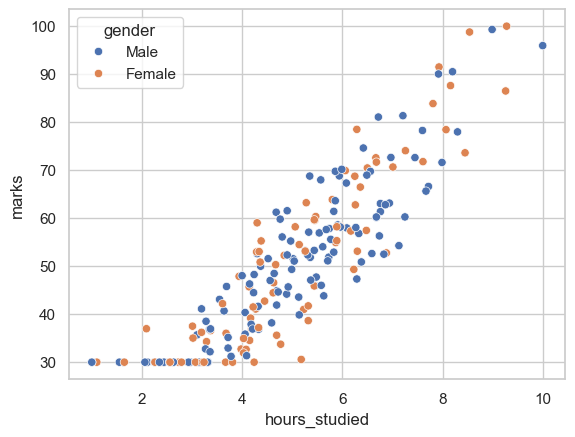

In [3]:
sns.scatterplot(data=students, x='hours_studied', y='marks', hue='gender')

### Problem 3

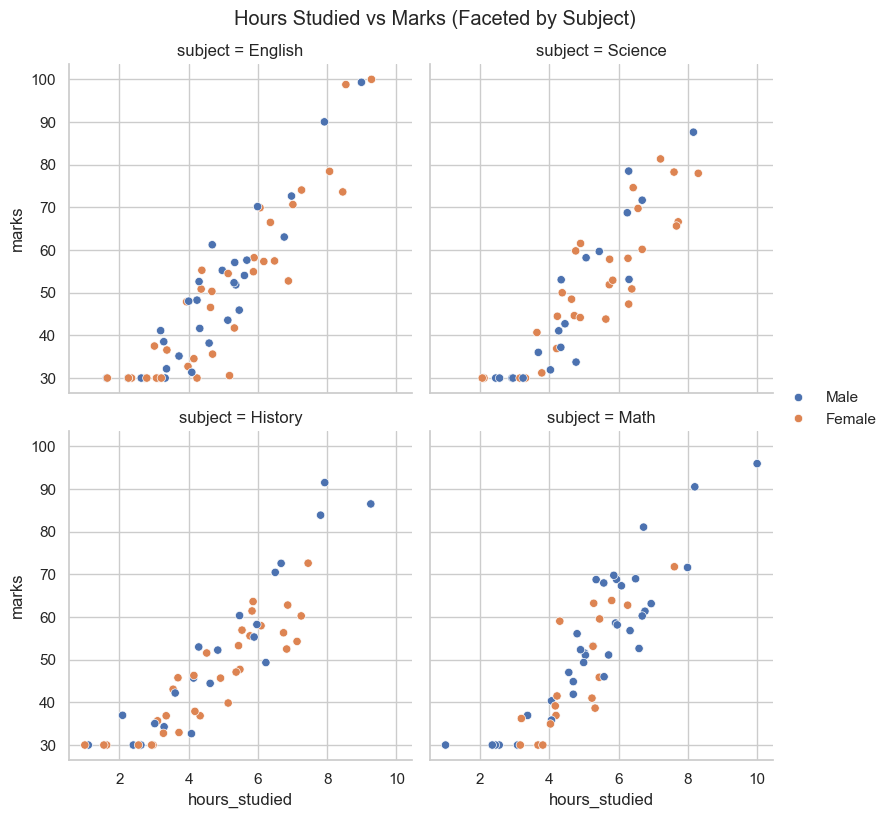

In [4]:
students
g = sns.FacetGrid(students, col="subject", col_wrap=2, height=4)
g.map_dataframe(sns.scatterplot, x="hours_studied", y="marks", hue="gender")
g.add_legend()
g.fig.suptitle("Hours Studied vs Marks (Faceted by Subject)", y=1.02)
plt.show()